# Sentiment Analysis Ulasan Play Store (Deep Learning)

Notebook ini melakukan analisis sentimen berdasarkan dataset hasil scraping pada `data/reviews_playstore_id.csv`.

Cakupan utama:
- Feature extraction
- Pelabelan 3 kelas (`negative`, `neutral`, `positive`)
- 3 skema pelatihan deep learning yang berbeda
- Evaluasi akurasi dan inference

In [5]:
%pip install -q tensorflow scikit-learn seaborn matplotlib pandas numpy

In [6]:
import os
import re
import random
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [7]:
DATA_PATH = Path("/content/reviews_playstore_id.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "File /content/reviews_playstore_id.csv belum ditemukan. Jalankan notebook scrapping.ipynb terlebih dahulu."
    )

df = pd.read_csv(DATA_PATH)
print("Shape data awal:", df.shape)
df.head()

Shape data awal: (10407, 9)


,review_id,app_id,app_name,user_name,score,content,thumbs_up,at,app_version
0,3855f346-979a-447f-a4d9-d038efe3823b,com.gojek.app,Gojek,Sunaryadi Sunaryadi,5,bagus,0,2026-04-25 21:07:51,NaN
1,78c81223-12ee-41fd-abda-95d5e529ee71,com.gojek.app,Gojek,Sri Wati,5,gojek keren nih apa saja kita perlu ada smuaa ..smoga smakin maju ya gojek,0,2026-04-25 21:06:50,5.56.2
2,8e0dc338-987a-4005-9ebe-3058c02f38b0,com.gojek.app,Gojek,Agus Solehudin,1,"KALIAN TAU GA KENAPA KALAU KALIAN ORDER GOFOOD SUKA LAMA DAPAT DRIVER? KADANG UDAH DAPAT DRIVER SUKA DIGANTUNG, LALU...",1,2026-04-25 21:05:39,NaN
3,0d7e9473-a421-4938-b2e2-2abbb0374e49,com.gojek.app,Gojek,Selamat Raharjo,5,mantul mantap betul 👍,0,2026-04-25 20:52:39,NaN
4,f636f419-1555-43c0-8b1d-9480d03fb996,com.gojek.app,Gojek,AL Dekhan,5,"ok sangat bermanfaat dan sangat"" membantu 🙏",0,2026-04-25 20:42:22,5.57.2


In [8]:
def label_from_score(score: int) -> str:
    if score <= 2:
        return "negative"
    if score == 3:
        return "neutral"
    return "positive"


def clean_text(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+|#\w+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


work_df = df.copy()
work_df = work_df.dropna(subset=["content", "score"]).drop_duplicates(subset=["review_id"])
work_df["content"] = work_df["content"].astype(str)
work_df = work_df[work_df["content"].str.len() > 3].reset_index(drop=True)

work_df["sentiment"] = work_df["score"].astype(int).apply(label_from_score)
work_df["text_clean"] = work_df["content"].apply(clean_text)
work_df = work_df[work_df["text_clean"].str.len() > 3].reset_index(drop=True)

label_to_id = {"negative": 0, "neutral": 1, "positive": 2}
id_to_label = {v: k for k, v in label_to_id.items()}
work_df["label_id"] = work_df["sentiment"].map(label_to_id)

print("Shape setelah preprocessing:", work_df.shape)
work_df[["score", "sentiment", "text_clean"]].head()

Shape setelah preprocessing: (10373, 12)


,score,sentiment,text_clean
0,5,positive,bagus
1,5,positive,gojek keren nih apa saja kita perlu ada smuaa smoga smakin maju ya gojek
2,1,negative,kalian tau ga kenapa kalau kalian order gofood suka lama dapat driver kadang udah dapat driver suka digantung lalu c...
3,5,positive,mantul mantap betul
4,5,positive,ok sangat bermanfaat dan sangat membantu


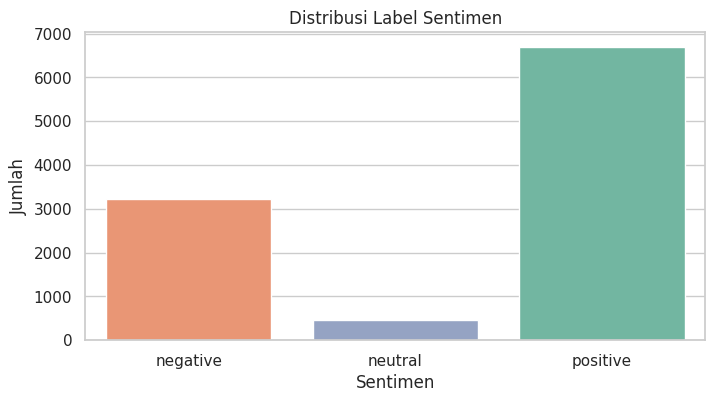

,count
sentiment,
positive,6698
negative,3216
neutral,459


In [26]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(
    data=work_df,
    x="sentiment",
    order=["negative", "neutral", "positive"],
    palette="Set2",
    hue="sentiment",
    legend=False
  )
ax.set_title("Distribusi Label Sentimen")
ax.set_xlabel("Sentimen")
ax.set_ylabel("Jumlah")
plt.show()

work_df["sentiment"].value_counts()

In [10]:
X = work_df["text_clean"].values
y = work_df["label_id"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("Jumlah data:")
print("Train:", len(X_train))
print("Val  :", len(X_val))
print("Test :", len(X_test))

Jumlah data:
Train: 7261
Val  : 1556
Test : 1556


In [11]:
MAX_TOKENS = 30000
SEQ_LENGTH = 120
BATCH_SIZE = 64
EPOCHS = 12


def compile_and_train(model, x_train, y_train, x_val, y_val, model_name: str):
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=2, mode="max", restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=1, min_lr=1e-5
        ),
    ]

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
        callbacks=callbacks,
    )

    return history


def evaluate_model(model, x_test, y_test, model_name: str):
    pred_probs = model.predict(x_test, verbose=0)
    y_pred = pred_probs.argmax(axis=1)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n[{model_name}] Test Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["negative", "neutral", "positive"]))
    return acc, y_pred

## Eksperimen 1: TF-IDF (TextVectorization) + Dense Neural Network

In [12]:
vectorizer_tfidf = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    standardize=None,
    output_mode="tf_idf",
)
vectorizer_tfidf.adapt(X_train)

inp = keras.Input(shape=(1,), dtype=tf.string)
x = vectorizer_tfidf(inp)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.35)(x)
x = layers.Dense(128, activation="relu")(x)
out = layers.Dense(3, activation="softmax")(x)

model_1 = keras.Model(inp, out, name="tfidf_dense")
model_1.summary()

Model: "tfidf_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 8180)           │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,094,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,127,619 (8.12 MB)

 Trainable params: 2,127,619 (8.12 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history_1 = compile_and_train(model_1, X_train, y_train, X_val, y_val, "TFIDF + Dense")
acc_1, pred_1 = evaluate_model(model_1, X_test, y_test, "TFIDF + Dense")

Epoch 1/12
114/114 ━━━━━━━━━━━━━━━━━━━━ 16s 78ms/step - accuracy: 0.8091 - loss: 0.5545 - val_accuracy: 0.8573 - val_loss: 0.4169 - learning_rate: 0.0010
Epoch 2/12
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9216 - loss: 0.2321 - val_accuracy: 0.8470 - val_loss: 0.4985 - learning_rate: 0.0010
Epoch 3/12
114/114 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9698 - loss: 0.1075 - val_accuracy: 0.8445 - val_loss: 0.5601 - learning_rate: 5.0000e-04

[TFIDF + Dense] Test Accuracy: 0.8573
              precision    recall  f1-score   support

    negative       0.78      0.83      0.80       483
     neutral       0.00      0.00      0.00        69
    positive       0.90      0.93      0.91      1004

    accuracy                           0.86      1556
   macro avg       0.56      0.59      0.57      1556
weighted avg       0.82      0.86      0.84      1556



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Eksperimen 2: Sequence + Embedding + BiLSTM

In [14]:
vectorizer_seq_lstm = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQ_LENGTH,
    standardize=None,
)
vectorizer_seq_lstm.adapt(X_train)

inp = keras.Input(shape=(1,), dtype=tf.string)
x = vectorizer_seq_lstm(inp)
x = layers.Embedding(MAX_TOKENS, 128, mask_zero=True)(x)
x = layers.Bidirectional(layers.LSTM(64))(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu")(x)
out = layers.Dense(3, activation="softmax")(x)

model_2 = keras.Model(inp, out, name="seq_bilstm")
model_2.summary()

Model: "seq_bilstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization… │ (None, 120)       │          0 │ input_layer_1[0]… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 120, 128)  │  3,840,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 120)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │     98,816 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 3)         │        195 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,947,267 (15.06 MB)

 Trainable params: 3,947,267 (15.06 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history_2 = compile_and_train(model_2, X_train, y_train, X_val, y_val, "Sequence + BiLSTM")
acc_2, pred_2 = evaluate_model(model_2, X_test, y_test, "Sequence + BiLSTM")

Epoch 1/12
114/114 ━━━━━━━━━━━━━━━━━━━━ 47s 360ms/step - accuracy: 0.7909 - loss: 0.5890 - val_accuracy: 0.8625 - val_loss: 0.4138 - learning_rate: 0.0010
Epoch 2/12
114/114 ━━━━━━━━━━━━━━━━━━━━ 39s 339ms/step - accuracy: 0.8904 - loss: 0.3292 - val_accuracy: 0.8657 - val_loss: 0.4105 - learning_rate: 0.0010
Epoch 3/12
114/114 ━━━━━━━━━━━━━━━━━━━━ 42s 346ms/step - accuracy: 0.9292 - loss: 0.2238 - val_accuracy: 0.8548 - val_loss: 0.4926 - learning_rate: 0.0010
Epoch 4/12
114/114 ━━━━━━━━━━━━━━━━━━━━ 38s 331ms/step - accuracy: 0.9599 - loss: 0.1350 - val_accuracy: 0.8400 - val_loss: 0.5747 - learning_rate: 5.0000e-04

[Sequence + BiLSTM] Test Accuracy: 0.8625
              precision    recall  f1-score   support

    negative       0.75      0.90      0.82       483
     neutral       0.00      0.00      0.00        69
    positive       0.93      0.90      0.92      1004

    accuracy                           0.86      1556
   macro avg       0.56      0.60      0.58      1556
weighte

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Eksperimen 3: Sequence + Embedding + CNN

In [16]:
vectorizer_seq_cnn = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQ_LENGTH,
    standardize=None,
)
vectorizer_seq_cnn.adapt(X_train)

inp = keras.Input(shape=(1,), dtype=tf.string)
x = vectorizer_seq_cnn(inp)
x = layers.Embedding(MAX_TOKENS, 128)(x)
x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(x)
x = layers.GlobalMaxPooling1D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu")(x)
out = layers.Dense(3, activation="softmax")(x)

model_3 = keras.Model(inp, out, name="seq_cnn")
model_3.summary()

Model: "seq_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_2            │ (None, 120)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 120, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 120, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,930,499 (14.99 MB)

 Trainable params: 3,930,499 (14.99 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history_3 = compile_and_train(model_3, X_train, y_train, X_val, y_val, "Sequence + CNN")
acc_3, pred_3 = evaluate_model(model_3, X_test, y_test, "Sequence + CNN")

Epoch 1/12
114/114 ━━━━━━━━━━━━━━━━━━━━ 17s 133ms/step - accuracy: 0.7796 - loss: 0.5710 - val_accuracy: 0.8477 - val_loss: 0.4292 - learning_rate: 0.0010
Epoch 2/12
114/114 ━━━━━━━━━━━━━━━━━━━━ 15s 135ms/step - accuracy: 0.8803 - loss: 0.3485 - val_accuracy: 0.8541 - val_loss: 0.4257 - learning_rate: 0.0010
Epoch 3/12
114/114 ━━━━━━━━━━━━━━━━━━━━ 15s 132ms/step - accuracy: 0.9150 - loss: 0.2555 - val_accuracy: 0.8522 - val_loss: 0.4544 - learning_rate: 0.0010
Epoch 4/12
114/114 ━━━━━━━━━━━━━━━━━━━━ 14s 127ms/step - accuracy: 0.9379 - loss: 0.1840 - val_accuracy: 0.8496 - val_loss: 0.4955 - learning_rate: 5.0000e-04

[Sequence + CNN] Test Accuracy: 0.8490
              precision    recall  f1-score   support

    negative       0.77      0.82      0.79       483
     neutral       0.00      0.00      0.00        69
    positive       0.89      0.92      0.91      1004

    accuracy                           0.85      1556
   macro avg       0.55      0.58      0.57      1556
weighted a

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
results_df = pd.DataFrame(
    {
        "experiment": [
            "Exp-1 TFIDF + Dense",
            "Exp-2 Sequence + BiLSTM",
            "Exp-3 Sequence + CNN",
        ],
        "test_accuracy": [acc_1, acc_2, acc_3],
    }
).sort_values("test_accuracy", ascending=False).reset_index(drop=True)

results_df

,experiment,test_accuracy
0,Exp-2 Sequence + BiLSTM,0.862468
1,Exp-1 TFIDF + Dense,0.857326
2,Exp-3 Sequence + CNN,0.848972


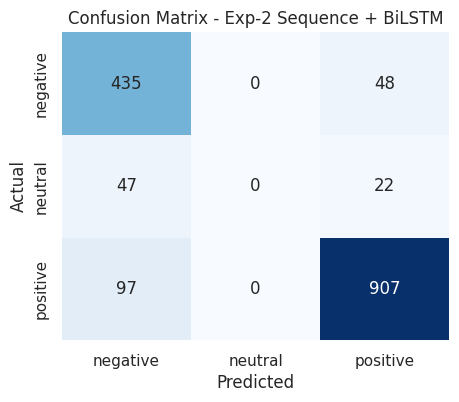

Best model: Exp-2 Sequence + BiLSTM


In [19]:
predictions = {
    "Exp-1 TFIDF + Dense": (model_1, pred_1),
    "Exp-2 Sequence + BiLSTM": (model_2, pred_2),
    "Exp-3 Sequence + CNN": (model_3, pred_3),
}

best_experiment = results_df.loc[0, "experiment"]
best_model, best_pred = predictions[best_experiment]

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["negative", "neutral", "positive"],
            yticklabels=["negative", "neutral", "positive"])
plt.title(f"Confusion Matrix - {best_experiment}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Best model:", best_experiment)

In [23]:
def predict_sentiment(texts):
    cleaned = [clean_text(t) for t in texts]
    # Explicitly convert the list of strings to a tf.constant with dtype=tf.string
    probs = best_model.predict(tf.constant(cleaned, dtype=tf.string), verbose=0)
    labels = probs.argmax(axis=1)
    return [id_to_label[int(i)] for i in labels], probs

sample_texts = [
    "Aplikasinya sangat membantu dan fiturnya lengkap.",
    "Lumayan, tapi kadang loading lama.",
    "Sangat mengecewakan, sering error dan tidak bisa dipakai.",
]

sample_labels, sample_probs = predict_sentiment(sample_texts)

pd.DataFrame(
    {
        "text": sample_texts,
        "predicted_sentiment": sample_labels,
        "confidence": sample_probs.max(axis=1),
    }
)

,text,predicted_sentiment,confidence
0,Aplikasinya sangat membantu dan fiturnya lengkap.,positive,0.995475
1,"Lumayan, tapi kadang loading lama.",positive,0.571710
2,"Sangat mengecewakan, sering error dan tidak bisa dipakai.",negative,0.839237


## Project Criteria

In [ ]:
with open('/content/criteria.md', 'r') as f:
    criteria_content = f.read()
print(criteria_content)